In [ ]:
import pandas as pd
from connec_functions import GDB
import requests
import time
import json

### Interoperability Assessment of ICOS Carbon SPARQL Endpoint

### Endpoint

In [18]:
# The given endpoint is the human-facing (UI) SPARQL Endpoint
browser_endpoint = "https://meta.icos-cp.eu/sparqlclient/?type=CSV"

In [19]:
# The machine-facing (API) SPARQL Endpoint is:
cli_endpoint = "https://meta.icos-cp.eu/sparql"

##### Table Of Content

- [Understanding the SPARQL endpoint structure](#understanding-sparql-endopint-structure)
- [Technical interoperability](#technical-interoperability)
    - [SPARQL protocol support](#sparql-protocol-support)
    - [Content negotiation and format support](#content-negotiation-and-format-support) 
    - [Endpoint connectivity and performance](#endpoint-connectivity-and-performance)
- [Semantic interoperability](#semantic-interoperability)
    - [Use of standard vocabularies](#use-of-standard-vocabularies)
    - [Ontology usage and semantic alignment](#ontology-usage-and-semantic-alignment)
    - [Use of linked data principles (URIs)](#use-of-linked-data-principles-uris)
    - [Multilingual support](#multilingual-support)
    - ([note on Reasoning](#note-on-reasoning))
    - ([note on Data Granularity](#note-on-data-granularity))


### Understanding the SPARQL endpoint structure
*Involves getting to understand the underlying RDF graph structure*

In [22]:
# Test browser/UI endpoint vs. CLI/API endpoint
params = {
    "query": "SELECT * WHERE { ?s ?p ?o } LIMIT 1"
}
headers = {
    "Accept": "application/sparql-results+json"
}

resp_ui = requests.get(browser_endpoint, params=params, headers=headers)
print("UI endpoint status:", resp_ui.status_code)

resp_api = requests.get(cli_endpoint, params=params, headers=headers)
print("API endpoint status:", resp_api.status_code)

UI endpoint status: 406
API endpoint status: 200


In [ ]:
#gdb = GDB(cli_endpoint, "endpoint_queries")
#gdb.execute_to_df("general.sparql")

#returns HTTP Error 501: Not Implemented 

cli_endpoint in browser returns  
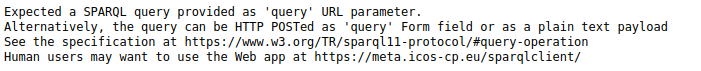

In [4]:
#Different approach
payload = {
    "query": "SELECT * WHERE { ?s ?p ?o } LIMIT 10"  # simple SPARQL query
}

def query_endpoint(url, payload=None):
    results = {}
    
    try:
        response = requests.post(url, data=payload)
        json_output = response.json()
        data = []
        for binding in json_output['results']['bindings']:
            row = {}
            for var in json_output['head']['vars']:
                # Sometimes the variable might be missing in some bindings, so use .get()
                val = binding.get(var)
                row[var] = val['value'] if val else None
            data.append(row)
    except Exception as e:
        return e

    return pd.DataFrame(data)

# Run test
result = query_endpoint(cli_endpoint, payload=payload)
result

,s,p,o
0,https://meta.fieldsites.se/objects/8uNF3qqyXBc...,http://meta.icos-cp.eu/ontologies/cpmeta/wasAc...,https://meta.fieldsites.se/resources/acq_8uNF3...
1,https://meta.fieldsites.se/objects/8uNF3qqyXBc...,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,http://meta.icos-cp.eu/ontologies/cpmeta/DataO...
2,https://meta.fieldsites.se/objects/8uNF3qqyXBc...,http://meta.icos-cp.eu/ontologies/cpmeta/hasNu...,245424
3,https://meta.fieldsites.se/objects/8uNF3qqyXBc...,http://meta.icos-cp.eu/ontologies/cpmeta/hasOb...,https://meta.fieldsites.se/resources/objspecs/...
4,https://meta.fieldsites.se/objects/8uNF3qqyXBc...,http://meta.icos-cp.eu/ontologies/cpmeta/hasSh...,8uNF3qqyXBclYG7mBFj9Adn4zptmkYGTCtwRT67DzWY
5,https://meta.fieldsites.se/objects/8uNF3qqyXBc...,http://meta.icos-cp.eu/ontologies/cpmeta/wasSu...,https://meta.fieldsites.se/resources/subm_8uNF...
6,https://meta.fieldsites.se/objects/8uNF3qqyXBc...,http://meta.icos-cp.eu/ontologies/cpmeta/hasSi...,24737565
7,https://meta.fieldsites.se/objects/8uNF3qqyXBc...,http://meta.icos-cp.eu/ontologies/cpmeta/hasName,SITES_MET_SVB_DEG_20010101-20150101_L2_30min.csv
8,https://meta.fieldsites.se/objects/8uNF3qqyXBc...,http://meta.icos-cp.eu/ontologies/cpmeta/hasAc...,"[""TIMESTAMP"", ""TA"", ""D_SNOW"", ""NETRAD"", ""P"", ""..."
9,http://meta.icos-cp.eu/ontologies/cpmeta/wasAc...,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,http://www.w3.org/2002/07/owl#ObjectProperty


**Ontologies**

`<http://meta.icos-cp.eu/ontologies/stationentry/>`

![Local Image](images/ICOS_CP_stationentry_ontology.png)


`<http://meta.icos-cp.eu/ontologies/cpmeta/>`  
(this is a preliminary diagram (not all classes/predicates are included!))

![Local Image](images/ICOS_CP_cpmeta_ontology.png)


**Datamodel**

instance example stationentry  
![stationentry_datamodel_instance diagram](./images/ICOS_CP_stationentry_datamodel_instance_example.png)


instance example cpmeta  
... *to add diagram image (if feasible)*

preliminary notes on exploration of underlying graph structure:
- sparql endpoint returns both data and ontology + also includes various representations of data (e.g. dcat representation and )

- SPARQL endpoints includes 4 owl:Ontology
    - `<http://meta.icos-cp.eu/resources/cpmeta/>`  ~ simply import the next one...
    - `<http://meta.icos-cp.eu/ontologies/cpmeta/>`
    - `<http://meta.icos-cp.eu/ontologies/otcmeta/>`
    - `<http://meta.icos-cp.eu/ontologies/stationentry/>`
- ontology itself not available? 
    - http://meta.icos-cp.eu/ontologies/stationentry/ results in download of `stationsschema.rdf` which doesn't return valid RDF
    - http://meta.icos-cp.eu/ontologies/otcmeta/ results in download of `otcschema.rdf` which also doesn't return valid RDF
    - http://meta.icos-cp.eu/ontologies/cpmeta/ results in download of `instanceschema.rdf` which also doesn't return valid RDF
    - ontology terms are available and described on html document

- (cpmeta:hasKeywords) keywords are currently stored as string (represent list of keywords); these could be stored as array of standard terms...
- ValueFormat classes do not reference already existing value formats (e.g. float32, iso8601date, ....)

- standard terms are defined as owl:NamedIndividual, rather than as a skos:Concept like in argo ontology...

- there appear to 2 representations of stations:  
    - <http://meta.icos-cp.eu/resources/stations/ES_SE-Svb>	
    - <https://meta.fieldsites.se/resources/stations/Svartberget>
both are described in RDF  
but do not appear to be linked to each other 

![image.png](attachment:image.png)
--> note the reference to <http://envri.eu/dcat#Site>  
there is also further along in the results <http://inspire.ec.europa.eu/metadata-codelist/TopicCategory/environment> 



side note:
what is the difference between <http://meta.icos-cp.eu/ontologies/cpmeta/hasResponsibleOrganization> and <https://meta.fieldsites.se/ontologies/sites/hasResponsibleOrganization> ?

(they both occur in the result of following query:
SELECT DISTINCT ?predicate ?object WHERE { <https://meta.fieldsites.se/resources/stations/Svartberget> ?predicate ?object } )

note one reasoning: 
- in cpmeta ontology, though "AtmoStation", "SailDrone", ... are a kind of "Station", 
- query to list all of type "Station", only includes the "Station" type  
- indication that no owl reasoning set?!


Properties within different ICOS domains (terrestrial, marine & ocean, atmospheric)

### Technical interoperability

#### SPARQL protocol support 
*Involves checking the version and supported features*

To fully comply with the SPARQL 1.1 Protocol (per [W3C spec](https://www.w3.org/TR/sparql11-protocol/)), an endpoint must support specific HTTP request types (methods) and media types for two main functionalities:

1. SPARQL Query (Read operations)

(Support for SELECT, ASK, DESCRIBE, CONSTRUCT)
| HTTP Method | Content-Type                        | Required                             |
| ----------- | ----------------------------------- | ------------------------------------ |
| **GET**     | N/A (query via URL)                 | ✔️ Yes                               |
| **POST**    | `application/x-www-form-urlencoded` | ✔️ Yes                               |
| **POST**    | `application/sparql-query`          | ⚠️ Optional, but strongly encouraged |


- Accept headers for content negotiation should also be supported:
    - application/sparql-results+json
    - application/sparql-results+xml
    - application/rdf+xml, text/turtle, etc. for CONSTRUCT/DESCRIBE


2. SPARQL Update (Write operations)

(Support for INSERT, DELETE, LOAD, etc.)
| HTTP Method | Content-Type                | Required |
| ----------- | --------------------------- | -------- |
| **POST**    | `application/sparql-update` | ✔️ Yes   |


- Only POST is allowed for SPARQL Update — GET is not valid.
- Responses are typically empty or with status 204 No Content.


3. Content Negotiation

The endpoint must respond appropriately based on the Accept header:
- For SELECT, ASK: support application/sparql-results+json, ...+xml
- For CONSTRUCT, DESCRIBE: support at least one RDF serialization:
    - application/rdf+xml, text/turtle, application/ld+json, etc.


4. Response Codes and Compliance

- Return 200 OK for valid queries.
- Return 400 Bad Request or 500 Internal Server Error for syntax/logic errors.
- May support OPTIONS for preflight (CORS-related, not required by SPARQL spec).



Summary Table:
| Function            | HTTP Method | Content-Type                        | Required                        |
| ------------------- | ----------- | ----------------------------------- | ------------------------------- |
| Query (GET)         | `GET`       | URL parameter `?query=`             | ✔️                              |
| Query (POST)        | `POST`      | `application/x-www-form-urlencoded` | ✔️                              |
| Query (POST raw)    | `POST`      | `application/sparql-query`          | ⚠️ Optional                     |
| Update              | `POST`      | `application/sparql-update`         | ✔️                              |
| Content Negotiation | `GET/POST`  | `Accept` header for result formats  | ✔️                              |
| Preflight/CORS      | `OPTIONS`   | N/A                                 | ❌ Not part of spec, but helpful |



In [24]:
def test_read_operations(endpoint, read_type="SELECT"):
    print(f"📥 Testing SPARQL 1.1 READ Operation: {read_type}\n")

    queries = {
        "SELECT": "SELECT * WHERE { ?s ?p ?o } LIMIT 1",
        "ASK": "ASK { ?s ?p ?o }",
        "CONSTRUCT": "CONSTRUCT { <http://example.org/res> ?p ?o } WHERE { <http://example.org/res> ?p ?o }",
        "DESCRIBE": "DESCRIBE <http://example.org/res>"
    }

    if read_type not in queries:
        print(f"❌ Unsupported query type: '{read_type}'. Choose from: {list(queries.keys())}")
        return

    query = queries[read_type]

    # Adjust Accept header based on type of expected result
    accept = (
        "application/sparql-results+json"
        if read_type in ["SELECT", "ASK"]
        else "text/turtle"
    )

    try:
        r_get = requests.get(endpoint, params={"query": query}, headers={"Accept": accept})
        print("GET:", r_get.status_code, r_get.headers.get("Content-Type"))
    except Exception as e:
        print("GET Error:", e)

    try:
        r_post_form = requests.post(endpoint, data={"query": query}, headers={"Accept": accept})
        print("POST form:", r_post_form.status_code, r_post_form.headers.get("Content-Type"))
    except Exception as e:
        print("POST form Error:", e)

    try:
        r_post_raw = requests.post(endpoint, data=query, headers={
            "Content-Type": "application/sparql-query",
            "Accept": accept
        })
        print("POST raw:", r_post_raw.status_code, r_post_raw.headers.get("Content-Type"))
    except Exception as e:
        print("POST raw Error:", e)

In [25]:
test_read_operations(cli_endpoint, "SELECT")

📥 Testing SPARQL 1.1 READ Operation: SELECT

GET: 200 application/sparql-results+json; charset=UTF-8
POST form: 200 application/sparql-results+json; charset=UTF-8
POST raw: 200 application/sparql-results+json; charset=UTF-8


In [26]:
test_read_operations(cli_endpoint, "ASK")

📥 Testing SPARQL 1.1 READ Operation: ASK

GET: 501 text/plain; charset=UTF-8
POST form: 501 text/plain; charset=UTF-8
POST raw: 501 text/plain; charset=UTF-8


In [27]:
test_read_operations(cli_endpoint, "CONSTRUCT")

📥 Testing SPARQL 1.1 READ Operation: CONSTRUCT

GET: 200 text/turtle; charset=UTF-8
POST form: 200 text/turtle; charset=UTF-8
POST raw: 200 text/turtle; charset=UTF-8


In [28]:
test_read_operations(cli_endpoint, "DESCRIBE")

📥 Testing SPARQL 1.1 READ Operation: DESCRIBE

GET: 200 text/turtle; charset=UTF-8
POST form: 200 text/turtle; charset=UTF-8
POST raw: 200 text/turtle; charset=UTF-8


In [29]:
def test_write_operations(endpoint_url, operation_type="INSERT DATA"):
    updates = {
        "INSERT DATA": """
            INSERT DATA {
                <http://example.org/test> <http://example.org/prop> "test_insert" .
            }
        """,
        "DELETE DATA": """
            DELETE DATA {
                <http://example.org/test> <http://example.org/prop> "test_insert" .
            }
        """,
        "DELETE/INSERT": """
            DELETE {
                <http://example.org/test> <http://example.org/prop> "old_value" .
            }
            INSERT {
                <http://example.org/test> <http://example.org/prop> "new_value" .
            }
            WHERE {
                OPTIONAL { <http://example.org/test> <http://example.org/prop> "old_value" }
            }
        """,
        "CLEAR DEFAULT": """
            CLEAR DEFAULT
        """
    }

    headers = {
        "Content-Type": "application/sparql-update"
    }

    print(f"📝 Testing SPARQL 1.1 Write Operation: {operation_type}\n")

    if operation_type not in updates:
        print(f"❌ Unsupported operation type: '{operation_type}'. Choose from: {list(updates.keys())}")
        return

    update_query = updates[operation_type]

    try:
        response = requests.post(endpoint_url, data=update_query.strip(), headers=headers, timeout=10)
        print(f"Status: {response.status_code} | Content-Type: {response.headers.get('Content-Type')}")
        if response.status_code >= 400:
            print("⚠️  Error response:", response.text[:200])
    except Exception as e:
        print("❌ Request failed:", e)


In [30]:
test_write_operations(cli_endpoint, "INSERT DATA")

📝 Testing SPARQL 1.1 Write Operation: INSERT DATA

Status: 400 | Content-Type: text/plain; charset=UTF-8
⚠️  Error response: Encountered " "insert" "INSERT "" at line 1, column 1.
Was expecting one of:
    "base" ...
    "prefix" ...
    "select" ...
    "construct" ...
    "describe" ...
    "ask" ...
    


In [31]:
test_write_operations(cli_endpoint, "DELETE DATA")

📝 Testing SPARQL 1.1 Write Operation: DELETE DATA

Status: 400 | Content-Type: text/plain; charset=UTF-8
⚠️  Error response: Encountered " "delete" "DELETE "" at line 1, column 1.
Was expecting one of:
    "base" ...
    "prefix" ...
    "select" ...
    "construct" ...
    "describe" ...
    "ask" ...
    


In [32]:
test_write_operations(cli_endpoint, "DELETE/INSERT")

📝 Testing SPARQL 1.1 Write Operation: DELETE/INSERT

Status: 400 | Content-Type: text/plain; charset=UTF-8
⚠️  Error response: Encountered " "delete" "DELETE "" at line 1, column 1.
Was expecting one of:
    "base" ...
    "prefix" ...
    "select" ...
    "construct" ...
    "describe" ...
    "ask" ...
    


In [33]:
test_write_operations(cli_endpoint, "CLEAR DEFAULT")

📝 Testing SPARQL 1.1 Write Operation: CLEAR DEFAULT

Status: 400 | Content-Type: text/plain; charset=UTF-8
⚠️  Error response: Encountered " "clear" "CLEAR "" at line 1, column 1.
Was expecting one of:
    "base" ...
    "prefix" ...
    "select" ...
    "construct" ...
    "describe" ...
    "ask" ...
    


#### Content negotiation and format support 

both human-faced and machine-faced SPARQL endpoint were consulted for the assessment of this part

In [34]:
def get_header_info(endpoint):
    headers = {
        "Origin": "https://example.com"  # You can change this to any origin you want to simulate
    }

    response = requests.get(endpoint, headers=headers)
    server_headers = response.headers

    return {
        # General protocol and status checks
        "General protocol and status checks" : 
            {
            "HTTP/HTTPS Protocol": endpoint.startswith("http"),
            "Status Code 200 OK": response.status_code == 200,
            },
        # Content negotiation
        "Content negotiation" : 
            {
            "MIME Type Present": "Content-Type" in server_headers,
            "MIME Type": server_headers.get("Content-Type"),
            "Content Negotiation Support": "Vary" in server_headers or "Accept" in server_headers,
            "Vary": server_headers.get("Vary"),                         # response may change depending on 'Accept-Encoding'
            "Accept-Ranges": server_headers.get("Accept-Ranges"),       # support partial content requests (e.g., 'bytes')
            },
        # Content negotiation related headers
        "Content negotiation related headers" : 
            { 
            "Content-Length": server_headers.get("Content-Length"),             # total size of the file, if specified
            "Content-Disposition": server_headers.get("Content-Disposition"),   # tells if file is inline or attachment
            "Content-Encoding": server_headers.get("Content-Encoding"),         # compression format (e.g., gzip)
            "Accept": server_headers.get("Accept"),                             # what media types the client accepts (rare in response)
            "Accept-Encoding": server_headers.get("Accept-Encoding"),           # what compression formats the client accepts (rare in response)
            },
        # Caching-related headers
        "Caching-related headers" : 
            {
            "Cache-Control": server_headers.get("Cache-Control"),       # caching policy (e.g., no-cache, max-age)
            "ETag": server_headers.get("ETag"),                         # version identifier for the file, useful for caching and validation
            },
        # CORS related headers
        "CORS-related headers": {
            "Access-Control-Allow-Origin": server_headers.get("Access-Control-Allow-Origin"),  # which origins can access the resource, expected response: access-control-allow-origin: * OR http://test.vliz.be
        }
    }

In [35]:
get_header_info(browser_endpoint)

{'General protocol and status checks': {'HTTP/HTTPS Protocol': True,
  'Status Code 200 OK': True},
 'Content negotiation': {'MIME Type Present': True,
  'MIME Type': 'text/html; charset=UTF-8',
  'Content Negotiation Support': False,
  'Vary': None,
  'Accept-Ranges': None},
 'Content negotiation related headers': {'Content-Length': None,
  'Content-Disposition': None,
  'Content-Encoding': 'gzip',
  'Accept': None,
  'Accept-Encoding': None},
 'Caching-related headers': {'Cache-Control': None, 'ETag': None},
 'CORS-related headers': {'Access-Control-Allow-Origin': None}}

In [36]:
get_header_info(cli_endpoint)

{'General protocol and status checks': {'HTTP/HTTPS Protocol': True,
  'Status Code 200 OK': False},
 'Content negotiation': {'MIME Type Present': True,
  'MIME Type': 'text/plain; charset=UTF-8',
  'Content Negotiation Support': False,
  'Vary': None,
  'Accept-Ranges': None},
 'Content negotiation related headers': {'Content-Length': '314',
  'Content-Disposition': None,
  'Content-Encoding': None,
  'Accept': None,
  'Accept-Encoding': None},
 'Caching-related headers': {'Cache-Control': None, 'ETag': None},
 'CORS-related headers': {'Access-Control-Allow-Origin': 'https://example.com'}}

In [37]:
# assess formats returned by cli_endpoint
query = "CONSTRUCT { ?s ?p ?o } WHERE { ?s ?p ?o } LIMIT 1"
formats = {
    "SPARQL JSON": "application/sparql-results+json",
    "SPARQL XML": "application/sparql-results+xml",
    "RDF/XML": "application/rdf+xml",
    "Turtle": "text/turtle",
    "JSON-LD": "application/ld+json"
}

for name, mime in formats.items():
    headers = {"Accept": mime}
    params = {"query": query}
    
    try:
        r = requests.get(cli_endpoint, headers=headers, params=params, timeout=10)
        status = r.status_code
        ctype = r.headers.get("Content-Type", "")
        print(f"{name:15} → {status} | {ctype}")
    except Exception as e:
        print(f"{name:15} → ERROR: {e}")

SPARQL JSON     → 406 | text/plain; charset=UTF-8
SPARQL XML      → 406 | text/plain; charset=UTF-8
RDF/XML         → 200 | application/rdf+xml; charset=UTF-8
Turtle          → 200 | text/turtle; charset=UTF-8
JSON-LD         → 406 | text/plain; charset=UTF-8


formats returned by `browser_endpoint` include:
- JSON → correct
- CSV → correct
- XML → correct
- TSV or Turtle → correct 

All shown in browser, no download

#### Endpoint connectivity and performance 
*Includes checking endpoint availability, connectivity, perofrmance and timeout handling*

check ook 'http monitoring tools' in google

In [40]:
# Optional: a simple test payload (SPARQL query in POST body, for example)
# This depends on the endpoint API; here we just send an empty or small query
payload = {
    "query": "SELECT * WHERE { ?s ?p ?o } LIMIT 10"  # simple SPARQL query
}
headers = {
    "Accept": "application/sparql-results+json"
}

# Configuration
timeout_seconds = 60

def test_endpoint(url, payload=None, headers=None, timeout=5):
    results = {}
    
    start_time = time.time()
    try:
        response = requests.post(url, data=payload, headers=headers, timeout=timeout)
        elapsed = time.time() - start_time

        results["reachable"] = True
        results["status_code"] = response.status_code
        results["response_time_seconds"] = round(elapsed, 3)
        results["success"] = response.ok
        results["content_preview"] = response.json()  # first 200 chars
    except requests.exceptions.Timeout:
        results["reachable"] = False
        results["error"] = f"Request timed out after {timeout} seconds"
    except requests.exceptions.ConnectionError as e:
        results["reachable"] = False
        results["error"] = f"Connection error: {e}"
    except Exception as e:
        results["reachable"] = False
        results["error"] = str(e)

    return results

# Run test
result = test_endpoint(cli_endpoint, payload=payload, headers=headers, timeout=timeout_seconds)
result

{'reachable': True,
 'status_code': 200,
 'response_time_seconds': 0.078,
 'success': True,
 'content_preview': {'head': {'vars': ['s', 'p', 'o']},
  'results': {'bindings': [{'s': {'type': 'uri',
      'value': 'https://meta.fieldsites.se/objects/8uNF3qqyXBclYG7mBFj9Adn4'},
     'p': {'type': 'uri',
      'value': 'http://meta.icos-cp.eu/ontologies/cpmeta/wasAcquiredBy'},
     'o': {'type': 'uri',
      'value': 'https://meta.fieldsites.se/resources/acq_8uNF3qqyXBclYG7mBFj9Adn4'}},
    {'s': {'type': 'uri',
      'value': 'https://meta.fieldsites.se/objects/8uNF3qqyXBclYG7mBFj9Adn4'},
     'p': {'type': 'uri',
      'value': 'http://www.w3.org/1999/02/22-rdf-syntax-ns#type'},
     'o': {'type': 'uri',
      'value': 'http://meta.icos-cp.eu/ontologies/cpmeta/DataObject'}},
    {'s': {'type': 'uri',
      'value': 'https://meta.fieldsites.se/objects/8uNF3qqyXBclYG7mBFj9Adn4'},
     'p': {'type': 'uri',
      'value': 'http://meta.icos-cp.eu/ontologies/cpmeta/hasNumberOfRows'},
     'o':

Findings

SPARQL protocol support
- ...

Content negotiation and format support
- ...

Endpoint connectivity and performance
- no timeout issues here


- sparql endpoint only queryable though browser interface, trying through code returns "501: Not Implemented"
- general queries take long time to run
- there is a set per-minute query quota

### Semantic interoperability

#### Use of standard vocabularies
Using terms from standard vocabularies and common ontologies is important for interoperability because it ensures that data exchanged between different systems carries consistent and well-defined meanings. These standardized terms create a common language that minimizes ambiguity and misunderstanding, enabling diverse datasets to be accurately linked and integrated. By adopting widely accepted ontologies, data producers and consumers can align their concepts and relationships, which facilitates seamless data exchange and supports automated reasoning. This shared semantic foundation also promotes cross-domain collaboration by allowing information from different fields or organizations to be combined effectively. In contrast, self-defined ontologies often lack broad adoption and clear alignment with established standards, making data more difficult to integrate and interpret, which ultimately hampers interoperability.

Findings
- Commonly accepted vocabularies/ontologies are being used  
*(listed in browser_endpoint)*
    - prefix dc: <http://purl.org/dc/elements/1.1/>  
    prefix dcat: <http://www.w3.org/ns/dcat#>  
    prefix dct: <http://purl.org/dc/terms/>  
    prefix dcterms: <http://purl.org/dc/terms/>  
    prefix geo: <http://www.opengis.net/ont/geosparql#>  
    prefix prov: <http://www.w3.org/ns/prov#>  
    prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#>  
    prefix ssn: <http://www.w3.org/ns/ssn/>  
    prefix xsd: <http://www.w3.org/2001/XMLSchema#>  


- Own ontologie(s):
    - `PREFIX cpmeta: <http://meta.icos-cp.eu/ontologies/cpmeta/>`  
    `PREFIX cpst: <http://meta.icos-cp.eu/ontologies/stationentry/>`  
    (prefix st: <http://meta.icos-cp.eu/ontologies/stationentry/>)  
    (prefix stentry: <http://meta.icos-cp.eu/ontologies/stationentry/>)  

- use of known & trusted standard terms for mediaType and license (e.g. MIME-Types using iana.org, licenses using CC-urls)


References to skos:Concepts from different namespaces  
...

- Use of internally defined ontologies
  - requires knowledge on the location of the ontologies / vocabularies and getting to know them ~~ less machine interoperable
  - sidenote: prefixes not registered on prefix.cc ~ would increase findability (+ also registering in ontology catalogues/archives)
- Also use of known & common ontologies such as dcat (see example SPARQL query "DCAT metadata demo")  
*(note: to facilitate integration of data between different sources it would be better is data is described using common & well known ontologies/vocabularies + potential extension to those if domain specific information cannot be described by those ontologies)*

#### Ontology usage and semantic alignment 
*Includes 'ontology and vocabulary compatibility', 'cross-dataset semantic linking', 'consistency of semantics'*

Ontology usage and semantic alignment are essential for interoperability because they provide different systems with a shared, machine-readable understanding of the concepts, relationships, and rules within data. Ontologies create a *common semantic framework* by defining vocabularies - such as classes and properties - and their precise meanings, allowing datasets from various sources to “speak the same language.” They help *disambiguate* terms that might have multiple meanings, like “temperature” or “station,” by linking them to exact definitions. Ontologies also *support reasoning* by formalizing relationships, such as subclass hierarchies and property constraints, enabling systems to infer new information and maintain consistent interpretation. Semantic alignment plays a key role in *bridging heterogeneous schemas* by mapping different terms for the same concept to common ontology terms or linking them through equivalence relations like owl:sameAs or skos:exactMatch. This alignment facilitates *cross-domain integration* - for example, connecting marine, climate, and biodiversity vocabularies - allowing comprehensive analysis across disciplines. Furthermore, by aligning ontologies and vocabularies, systems can automatically link and query datasets together, greatly *reducing the need for manual mapping* and enabling smoother data integration.

Findings:
- **ontology and vocabulary compatibility**  
...

- **cross-dataset semantic linking**  
...

- **consistency of semantics**  
...

Sidenotes:
- ontologies lack visualization 
- additionally, given large amount of self-defined terms in own ontologies, a visualization of the data model would be handy

#### Use of linked data principles (URIs)

Using Linked Data principles, particularly URIs, is vital for interoperability because URIs provide global uniqueness, ensuring that when two datasets reference the same URI (e.g., http://example.org/species/Thunnus_albacares), they refer to the exact same resource. As HTTP identifiers, URIs are resolvable, allowing users and machines to retrieve additional information—such as RDF descriptions, ontologies, or documentation—thereby reducing ambiguity. Their machine-readability enables automated linking, merging, and reasoning over RDF data. This foundation supports interoperability by allowing cross-dataset linking without naming conflicts, maintaining stable references even when data changes location, and ensuring semantic clarity through consistent links to ontologies or controlled vocabularies that define the meaning of terms across systems.


Findings:
- all subjects of triples are URIs (logical)
- 31% of objects of tripels are URIs
- rel. large % of objects of triples are datatype dateTime 
- note: SPARQL endpoint not performant enough to analyse all objects (limited to 10000 triples); hence findings are only indicative! 

In [ ]:
# IRI as subjects
payload = {
    "query": """
            SELECT DISTINCT ?subject (ISIRI(?subject) AS ?isIRI)
            WHERE {
              ?subject ?predicate ?object .
            }
            LIMIT 10000
            """
}

subj_iri = query_endpoint(cli_endpoint, payload=payload)
subj_iri

,subject,isIRI
0,https://meta.fieldsites.se/objects/8uNF3qqyXBc...,true
1,http://meta.icos-cp.eu/ontologies/cpmeta/wasAc...,true
2,https://meta.fieldsites.se/resources/acq_8uNF3...,true
3,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,true
4,http://meta.icos-cp.eu/ontologies/cpmeta/DataA...,true
...,...,...
9995,http://meta.icos-cp.eu/resources/prod_0QUBTGpt...,true
9996,https://meta.icos-cp.eu/objects/C5XIYtw98Sg8cI...,true
9997,http://meta.icos-cp.eu/resources/prod_C5XIYtw9...,true
9998,http://meta.icos-cp.eu/resources/subm_MtJYBO6t...,true


In [47]:
# % of IRIs 
subj_iri['isIRI'] = subj_iri['isIRI'].astype(str).str.lower().str.strip() == 'true'
percentage_isIRI = subj_iri['isIRI'].mean() * 100
print(f"Percentage of isIRI = True: {percentage_isIRI:.2f}%")

Percentage of isIRI = True: 100.00%


In [ ]:
# Datatypes of objects
payload = {
    "query": """
            SELECT DISTINCT 
            ?object
            (DATATYPE(?object) AS ?datatype)
            (ISIRI(?object) && STRSTARTS(STR(?object), "http") AS ?uri)
            WHERE {
            ?subject ?predicate ?object .
            }
            LIMIT 10000
            """
}

obj_datatype = query_endpoint(cli_endpoint, payload=payload)
obj_datatype

,object,datatype,uri
0,https://meta.fieldsites.se/resources/acq_8uNF3...,None,true
1,http://meta.icos-cp.eu/ontologies/cpmeta/DataO...,None,true
2,245424,http://www.w3.org/2001/XMLSchema#integer,false
3,https://meta.fieldsites.se/resources/objspecs/...,None,true
4,8uNF3qqyXBclYG7mBFj9Adn4zptmkYGTCtwRT67DzWY,http://www.w3.org/2001/XMLSchema#base64Binary,false
...,...,...,...
9995,SITES_CHEM_RBD_SP4_20160630-20231115.csv,http://www.w3.org/2001/XMLSchema#string,false
9996,2024-01-31T06:47:29.550315Z,http://www.w3.org/2001/XMLSchema#dateTime,false
9997,2024-01-31T06:47:33.259573Z,http://www.w3.org/2001/XMLSchema#dateTime,false
9998,https://meta.fieldsites.se/resources/acq_Uqlfw...,None,true


In [44]:
# % of IRIs 
obj_datatype['uri'] = obj_datatype['uri'].astype(str).str.lower().str.strip() == 'true'
percentage_isIRI = obj_datatype['uri'].mean() * 100
print(f"Percentage of isIRI = True: {percentage_isIRI:.2f}%")

# % of each datatype
unique_datatypes = obj_datatype['datatype'].unique()
for dt in unique_datatypes:
    percentage = (obj_datatype['datatype'] == dt).mean() * 100
    print(f"Percentage of datatype = {dt}: {percentage:.2f}%")


Percentage of isIRI = True: 30.91%
Percentage of datatype = None: 0.00%
Percentage of datatype = http://www.w3.org/2001/XMLSchema#integer: 4.20%
Percentage of datatype = http://www.w3.org/2001/XMLSchema#base64Binary: 10.33%
Percentage of datatype = http://www.w3.org/2001/XMLSchema#long: 10.09%
Percentage of datatype = http://www.w3.org/2001/XMLSchema#string: 13.13%
Percentage of datatype = http://www.w3.org/2001/XMLSchema#dateTime: 28.90%
Percentage of datatype = http://www.w3.org/2001/XMLSchema#double: 2.04%
Percentage of datatype = http://www.w3.org/2001/XMLSchema#float: 0.29%
Percentage of datatype = http://www.w3.org/2001/XMLSchema#anyURI: 0.10%
Percentage of datatype = http://www.w3.org/2001/XMLSchema#boolean: 0.01%


#### Multilingual support 
This ensures that data meaning is preserved and accessible across different languages and cultural contexts:  
- Preserves shared meaning:  
Using RDF features like rdfs:label and skos:prefLabel with language tags (@en, @fr, @es) ensures that terms have human-readable equivalents in multiple languages while sharing the same URI.
- Facilitates data discovery:  
Multilingual labels allow search and query interfaces to return results in the user’s preferred language without losing semantic accuracy.
- Aligns vocabularies globally:  
Multilingual terminologies reduce the risk of mismatches when integrating data from separate national or regional repositories.

Findings:  
- query returns empty result as indicated by the JSONDecodeError
- no support for (multiple) languages 

In [41]:
payload = {
    "query": """
            PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
            PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
            PREFIX dc: <http://purl.org/dc/elements/1.1/>

            SELECT DISTINCT (LANG(?label) AS ?lang)
            WHERE {
            ?s ?p ?label .
            VALUES ?p { rdfs:label skos:prefLabel dc:title }
            FILTER(LANG(?label) != "")
            }
            LIMIT 10000
            """
}

result = query_endpoint(cli_endpoint, payload=payload)
result

requests.exceptions.JSONDecodeError('Expecting value: line 1 column 1 (char 0)')

**Note on Reasoning**

Reasoning enhances semantic interoperability by enabling systems to interpret, align, and integrate heterogeneous data more effectively.   


How reasoning boosts interoperability:

1. **Bridging schema differences**:  
Reasoning can infer relationships between different vocabularies or ontologies, like recognizing that one class is a subclass of another or that two properties are equivalent. This helps integrate data from diverse sources smoothly.  

2. **Making implicit knowledge explicit**:  
Reasoners can derive facts not explicitly stated in the data, enabling applications to understand and use information more completely without requiring every detail to be spelled out upfront.  

3. **Supporting richer queries**:
By applying inference rules, queries can return results based on inferred knowledge, not just direct triples. This makes data from multiple sources more interoperable because the system “understands” the underlying concepts better.  

4. **Standardization via ontologies**:
Reasoning leverages shared vocabularies like RDFS and OWL, which are standards for describing data and relationships. This creates a common semantic ground that improves interoperability.  




In [ ]:
# from exploration of SPARQL endpoint, we got to know that there are several subclasses to the class Station
payload = {
    "query": """
            PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
            PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
            SELECT DISTINCT ?stationType
            WHERE { ?stationType rdfs:subClassOf <http://meta.icos-cp.eu/ontologies/cpmeta/Station> } 
            """
}

stationTypes = query_endpoint(cli_endpoint, payload=payload)
stationTypes

,stationType
0,https://meta.fieldsites.se/ontologies/sites/St...
1,http://meta.icos-cp.eu/ontologies/cpmeta/AtmoS...
2,http://meta.icos-cp.eu/ontologies/cpmeta/Fluxn...
3,http://meta.icos-cp.eu/ontologies/cpmeta/Ingos...
4,http://meta.icos-cp.eu/ontologies/cpmeta/SailD...
5,http://meta.icos-cp.eu/ontologies/cpmeta/Wdcgg...
6,http://meta.icos-cp.eu/ontologies/cpmeta/IcosS...
7,http://meta.icos-cp.eu/ontologies/cpmeta/IcosC...
8,http://meta.icos-cp.eu/ontologies/cpmeta/NeonS...


In [9]:
# however the sparql queries to list all stations doesn't inlcude the subclasses
payload = {
    "query": """
            PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
            SELECT DISTINCT ?s ?o
            WHERE { 
                ?s rdf:type <http://meta.icos-cp.eu/ontologies/cpmeta/Station> .
                ?s rdf:type ?o . 
            } 
            """
}

stations = query_endpoint(cli_endpoint, payload=payload)
stations

,s,o
0,http://meta.icos-cp.eu/resources/stations/MEMO...,http://meta.icos-cp.eu/ontologies/cpmeta/Station
1,http://meta.icos-cp.eu/resources/stations/MEMO...,http://meta.icos-cp.eu/ontologies/cpmeta/Station
2,http://meta.icos-cp.eu/resources/stations/USCB_PL,http://meta.icos-cp.eu/ontologies/cpmeta/Station
3,http://meta.icos-cp.eu/resources/stations/BEDF...,http://meta.icos-cp.eu/ontologies/cpmeta/Station
4,http://meta.icos-cp.eu/resources/stations/Jung...,http://meta.icos-cp.eu/ontologies/cpmeta/Station
...,...,...
241,http://meta.icos-cp.eu/resources/wdcgg/station...,http://meta.icos-cp.eu/ontologies/cpmeta/Station
242,http://meta.icos-cp.eu/resources/wdcgg/station...,http://meta.icos-cp.eu/ontologies/cpmeta/Station
243,http://meta.icos-cp.eu/resources/wdcgg/station...,http://meta.icos-cp.eu/ontologies/cpmeta/Station
244,http://meta.icos-cp.eu/resources/wdcgg/station...,http://meta.icos-cp.eu/ontologies/cpmeta/Station


In [14]:
stations['o'].unique()

array(['http://meta.icos-cp.eu/ontologies/cpmeta/Station'], dtype=object)

**Note on Data Granularity**

In SPARQL endpoints, data granularity refers to the level of detail in the RDF triples, which influences the ability of different systems and stakeholders to integrate, interpret, and reuse the data.

**How it matters in context of interoperability**  
In ocean observations, data can range from raw sensor readings every second to monthly aggregated summaries. The SPARQL endpoint’s granularity affects interoperability in these ways:
1. Matching with external datasets  
    - Fine-grained data (e.g., per-measurement triples for salinity, temperature, timestamp, location) aligns well with other detailed datasets—making it easier to merge and cross-query.
    - Coarse-grained data (e.g., “average temperature for June at Station X”) may align only with similarly aggregated datasets, limiting integration.

2. Supporting diverse user needs
    - Scientists might need raw, high-frequency measurements for detailed modelling.
    - Policy makers may only need coarser summaries.
    - If the endpoint only offers one granularity, some users will have to post-process data, reducing interoperability in practice.

3. Preserving semantic richness  
Fine-grained RDF can encode relationships explicitly—such as this salinity reading was taken by sensor A at depth 5 m at 2025-08-01T12:00 UTC.
That explicitness improves semantic interoperability because the context travels with the data.

For ocean observation data, granularity is a balancing act. The finer the detail in the SPARQL endpoint, the easier it is to integrate with heterogeneous external datasets and support a variety of use cases—at the cost of storage and query performance. Coarser granularity improves speed and simplicity but narrows interoperability to datasets with matching aggregation levels.  

granularity goes to file level 'cpmeta:DataObject's represent a.o. for example csv files , of which the structure/content is described in metadata, but to which a link to obtain the file is not available
((example DataObject: <https://meta.fieldsites.se/objects/8uNF3qqyXBclYG7mBFj9Adn4>))

In [ ]:
# - data granularity: file level
#  - data files are accessible with dcat:downloadUrl within a dcat:distribution (data points themselves are not described in RDF)